# spatialdetection quickstart

Interactive tour of the library. Every clustering/autocorrelation function
takes a plain `pandas.DataFrame` with `lon`/`lat` columns directly — no
need to build a `GeoDataFrame` yourself first.

Run all cells (Kernel > Restart & Run All), or open this in VS Code with the
Jupyter extension and pick the `spatialdetection` (`.venv`) kernel.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd

from spatialdetection import (
    cluster_summary,
    dbscan_clusters,
    detect_level,
    detect_point,
    district_hotspots,
    getis_ord_hotspots,
    morans_i,
    plot_level_map,
    province_hotspots,
    spatiotemporal_hotspots,
    subdistrict_hotspots,
)

rng = np.random.default_rng(0)

## 1. Sample data

Synthetic outbreak-style case data: a tight cluster plus scattered
background cases around Bangkok, each with a report date.

In [2]:
cluster = pd.DataFrame(
    {
        "lon": rng.normal(100.50, 0.01, size=30),
        "lat": rng.normal(13.75, 0.01, size=30),
        "cases": rng.poisson(8, size=30),
    }
)
background = pd.DataFrame(
    {
        "lon": rng.uniform(100.3, 100.7, size=40),
        "lat": rng.uniform(13.6, 13.9, size=40),
        "cases": rng.poisson(1, size=40),
    }
)
df = pd.concat([cluster, background], ignore_index=True)
days = pd.to_datetime("2024-06-01") + pd.to_timedelta(rng.integers(0, 5, size=len(df)), unit="D")
df["reported_at"] = days

df.head()

,lon,lat,cases,reported_at
0,100.501257,13.739904,6,2024-06-03
1,100.498679,13.747908,14,2024-06-01
2,100.506404,13.748408,10,2024-06-04
3,100.501049,13.755408,15,2024-06-03
4,100.494643,13.752147,4,2024-06-02


## 2. Density-based cluster detection (DBSCAN)

In [3]:
labels = dbscan_clusters(df, eps_km=1.5, min_samples=5)
summary = cluster_summary(df, labels)
summary[["cluster", "size"]]

,cluster,size
0,0,30


## 3. Spatial autocorrelation / hotspot detection

Global Moran's I tests whether `cases` is spatially clustered at all;
Getis-Ord Gi* flags exactly which points are significant hot/cold spots.

In [4]:
moran = morans_i(df, value_col="cases", k=5, permutations=199)
print(f"Global Moran's I: {moran.I:.3f} (p={moran.p_sim:.3f})")

hotspots = getis_ord_hotspots(df, value_col="cases", k=5, permutations=199)
hotspots["hotspot"].value_counts().rename({1: "hotspot", -1: "coldspot", 0: "not significant"})

Global Moran's I: 0.626 (p=0.005)


hotspot
not significant    31
coldspot           22
hotspot            17
Name: count, dtype: int64

<Axes: >

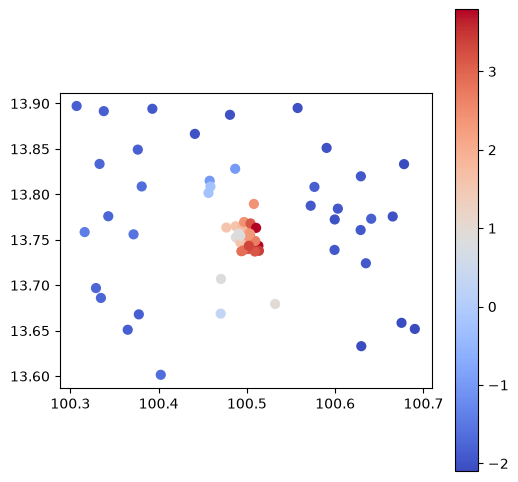

In [5]:
hotspots.plot(column="gi_zscore", cmap="coolwarm", legend=True, markersize=40, figsize=(6, 6))

## 4. Spatiotemporal hotspots

Bin points by day/week/month and run Getis-Ord Gi* independently within
each bin, so a hotspot in one period isn't diluted by activity in another.

In [6]:
by_day = spatiotemporal_hotspots(
    df, time_col="reported_at", value_col="cases", timeframe="day", k=5, permutations=199
)
by_day.groupby("time_bin")["hotspot"].apply(lambda s: (s == 1).sum()).rename("hotspot_points")

time_bin
2024-06-01    3
2024-06-02    7
2024-06-03    6
2024-06-04    8
2024-06-05    1
Name: hotspot_points, dtype: int64

## 5. Detect a Thai admin level and auto-plot it

`detect_level` accepts either a P-code string or a `(lat, lon)` pair and
auto-dispatches; `plot_level_map` renders a map zoomed to whatever level it
finds.

level=province, lat=13.7718, lon=100.6234


<Axes: title={'center': 'Province: Bangkok (TH10)'}>

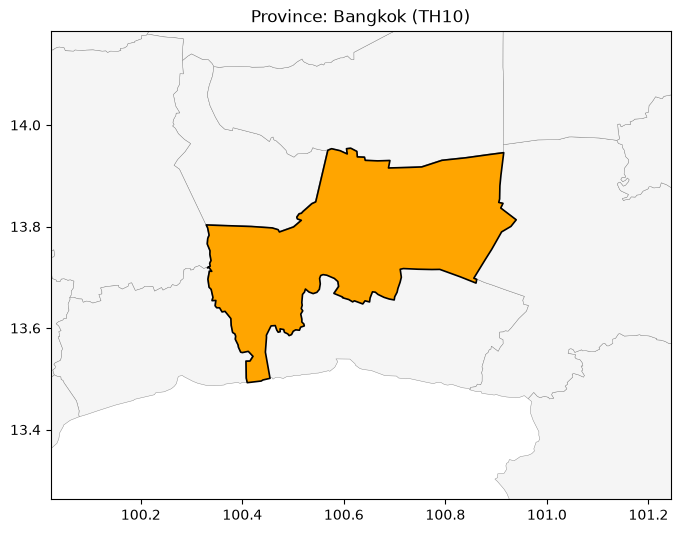

In [7]:
result = detect_level("TH10")  # Bangkok province P-code
print(f"level={result.level}, lat={result.lat:.4f}, lon={result.lon:.4f}")

plot_level_map("TH10")

## 6. Reverse-geocode points to P-codes

`detect_point` is the inverse of `detect_province`/`detect_district`/
`detect_subdistrict`: given a DataFrame of `(lat, lon)` rows, it spatially
resolves which province/district/subdistrict each one falls inside.

In [8]:
located = detect_point(df)
located.groupby("subdistrict_en")["cases"].sum().sort_values(ascending=False).head(10)

subdistrict_en
Phraborom Maharatchawang    34
Bowon Niwet                 29
Wang Burapha Phirom         24
Wat Kanlaya                 22
Talat Noi                   18
Sirirat                     17
Sao Chingcha                16
Bang Khun Phrom             13
Wat Thepsirin               13
Ban Phan Thom               12
Name: cases, dtype: int64

## 7. P-code-tagged data: describe, aggregate, and detect hotspots at every level

A larger, more realistic dataset: person-level records already tagged
with a subdistrict P-code (as real line-list data often does), spread
across multiple provinces over a 30-day window, with one outbreak
province. Thailand's P-code scheme is nested -- subdistrict `"TH100101"`
= district `"TH1001"` + 2 digits = province `"TH10"` + 2 more -- so the
parent district/province codes come from string slicing, no lookup
needed. See `examples/pcode_example.py` for the standalone script this
section mirrors.

In [9]:
def jittered_persons(s, n, start):
    return pd.DataFrame({
        "pcode": s["subdistrict_code"],
        "lat": rng.normal(s["lat"], 0.01, size=n),
        "long": rng.normal(s["lon"], 0.01, size=n),
        "date": start + pd.to_timedelta(rng.integers(0, 30, size=n), unit="D"),
    })

with open("../data/thailand_admin_centroids.json") as f:
    centroids = json.load(f)
subdistricts = pd.DataFrame(centroids["subdistricts"])
provinces = pd.DataFrame(centroids["provinces"])
by_province_en = subdistricts.merge(provinces[["province_code", "province_en"]], on="province_code")

background_provinces = ["Bangkok", "Chiang Mai", "Khon Kaen", "Nakhon Si Thammarat", "Songkhla", "Nakhon Ratchasima", "Chon Buri"]
outbreak_province = "Chiang Rai"  # not in the background list -> isolated signal
start = pd.to_datetime("2024-05-01")

rows = []
# Every province gets a small baseline -- Getis-Ord's permutation test
# handles "0 vs. 0" neighbor comparisons poorly, so leaving most provinces
# at a literal zero would bury the outbreak signal in that artifact.
baseline = subdistricts.groupby("province_code", as_index=False).first()
for _, s in baseline.iterrows():
    rows.append(jittered_persons(s, rng.integers(20, 80), start))

chosen = [by_province_en[by_province_en["province_en"] == p].sample(2, random_state=0) for p in background_provinces]
for _, s in pd.concat(chosen, ignore_index=True).iterrows():
    rows.append(jittered_persons(s, rng.integers(1500, 2500), start))

outbreak = by_province_en[by_province_en["province_en"] == outbreak_province].sample(1, random_state=1)
for _, s in outbreak.iterrows():
    rows.append(jittered_persons(s, 8_000, start))

person_df = pd.concat(rows, ignore_index=True)
print(f"{len(person_df)} person records across {person_df['date'].dt.date.nunique()} days")
person_df.head()

40930 person records across 30 days


,pcode,lat,long,date
0,TH100101,13.739208,100.476578,2024-05-21
1,TH100101,13.751241,100.492745,2024-05-30
2,TH100101,13.752709,100.480666,2024-05-13
3,TH100101,13.760089,100.478586,2024-05-11
4,TH100101,13.752627,100.489922,2024-05-29


### Data describe

In [10]:
person_df.describe(include="all")

,pcode,lat,long,date
count,40930,40930.000000,40930.000000,40930
unique,92,NaN,NaN,NaN
top,TH570511,NaN,NaN,NaN
freq,8000,NaN,NaN,NaN
mean,NaN,14.604415,100.640855,2024-05-15 11:42:58.314195
min,NaN,6.406028,97.936900,2024-05-01 00:00:00
25%,NaN,12.981733,99.683580,2024-05-08 00:00:00
50%,NaN,15.178066,100.427432,2024-05-15 00:00:00
75%,NaN,18.797965,101.051213,2024-05-23 00:00:00
max,NaN,19.931770,104.876280,2024-05-30 00:00:00


### Aggregate by pcode to subdistrict / district / province

No spatial join needed here -- `pcode` is already known per row, so the
parent district/province codes come from string slicing and the rollup
is a plain `groupby`.

In [11]:
person_df["district_code"] = person_df["pcode"].str[:6]
person_df["province_code"] = person_df["pcode"].str[:4]

by_subdistrict = person_df.groupby("pcode").size().rename("persons")
by_district = person_df.groupby("district_code").size().rename("persons")
by_province = person_df.groupby("province_code").size().rename("persons")
print(f"{len(by_subdistrict)} subdistricts, {len(by_district)} districts, {len(by_province)} provinces")
by_province.sort_values(ascending=False).head(8)

92 subdistricts, 90 districts, 77 provinces


province_code
TH57    8020
TH50    4775
TH20    4562
TH80    4462
TH40    4125
TH10    3977
TH90    3954
TH30    3670
Name: persons, dtype: int64

### Hotspot detection at every level

`province_hotspots`/`district_hotspots`/`subdistrict_hotspots` take the
same point-level data directly (lat/long), reverse-geocode it with
`detect_point`, and aggregate onto *every* unit at that level. Results
are ranked by count rather than filtered to `hotspot == 1`: with one
dominant outbreak among many small/baseline counts, the `gi_pvalue`
significance flag can be unreliable even when `gi_zscore` correctly
ranks the outbreak highest -- filtering to "significant" risks hiding
the real signal. Finer levels (subdistrict) also need denser data per
unit for `gi_pvalue` to be meaningful at all -- see `level_hotspots.py`.

In [12]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # libpysal disconnected-components notice
    prov_result = province_hotspots(person_df, lon_col="long", lat_col="lat", k=5, permutations=499)
    dist_result = district_hotspots(person_df, lon_col="long", lat_col="lat", k=5, permutations=199)
    sub_result = subdistrict_hotspots(person_df, lon_col="long", lat_col="lat", k=5, permutations=99)

print("Top provinces by person count:")
display(prov_result.sort_values("count", ascending=False)[["province_en", "count", "gi_zscore", "gi_pvalue", "hotspot"]].head(5))

Top provinces by person count:


,province_en,count,gi_zscore,gi_pvalue,hotspot
45,Chiang Rai,8020,2.893577,0.086,0
38,Chiang Mai,4752,0.564034,0.448,0
63,Nakhon Si Thammarat,4462,0.468082,0.258,0
28,Khon Kaen,4125,0.385335,0.476,0
0,Bangkok,3977,0.333104,0.356,0


In [13]:
print("Top districts by person count:")
display(dist_result.sort_values("count", ascending=False)[["district_en", "count", "gi_zscore", "gi_pvalue", "hotspot"]].head(5))

Top districts by person count:


,district_en,count,gi_zscore,gi_pvalue,hotspot
610,Phan,8000.0,8.705640,0.005,1
792,Hua Sai,4384.0,4.654682,0.455,0
363,Ban Fang,2409.0,2.512835,0.150,0
520,Chom Thong,2356.0,2.385785,0.420,0
523,Doi Saket,2143.0,2.326196,0.120,0


In [14]:
print("Top subdistricts by person count:")
display(sub_result.sort_values("count", ascending=False)[["subdistrict_en", "count", "gi_zscore", "gi_pvalue", "hotspot"]].head(5))

Top subdistricts by person count:


,subdistrict_en,count,gi_zscore,gi_pvalue,hotspot
4859,San Klang,7770.0,27.526371,0.02,1
2917,Nong Bua,2384.0,8.383345,0.04,1
6474,Sai Khao,2379.0,15.178841,0.02,1
4162,Sop Tia,2354.0,8.174360,0.09,0
1521,Khok Krabueang,2054.0,7.042358,0.01,1
